# SQL Query Performance Classification using Decision Tree

### 1.Problem Statement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn import tree

import joblib

### 2.Data Gathering

In [2]:
df=pd.read_csv("SQL_Query_Performance_Classification_Dataset.csv")
df.head()

,Query_Length,Number_of_Joins,Number_of_Where,Number_of_Subqueries,Has_GroupBy,Has_OrderBy,Has_Index,Table_Size,Estimated_Rows,Execution_Memory_MB,Performance
0,347.0,0.0,0.0,2.0,0.0,0.0,0.0,Medium,709670.0,83.0,Medium
1,64.0,4.0,3.0,0.0,0.0,0.0,0.0,Small,631362.0,64.0,Medium
2,307.0,1.0,5.0,3.0,0.0,1.0,1.0,Large,6914.0,57.0,Slow
3,377.0,3.0,2.0,2.0,0.0,0.0,1.0,Small,398482.0,87.0,Slow
4,203.0,2.0,4.0,2.0,0.0,1.0,0.0,Large,397022.0,67.0,Slow


In [3]:
df.tail()

,Query_Length,Number_of_Joins,Number_of_Where,Number_of_Subqueries,Has_GroupBy,Has_OrderBy,Has_Index,Table_Size,Estimated_Rows,Execution_Memory_MB,Performance
1025,270.0,3.0,0.0,2.0,1.0,1.0,0.0,Small,58877.0,66.0,Medium
1026,100.0,3.0,3.0,3.0,1.0,0.0,1.0,Medium,327866.0,79.0,Slow
1027,131.0,5.0,1.0,2.0,0.0,0.0,NaN,Large,528787.0,99.0,Slow
1028,89.0,4.0,4.0,0.0,NaN,0.0,0.0,Large,261709.0,48.0,Slow
1029,88.0,4.0,6.0,3.0,1.0,0.0,1.0,Medium,144292.0,74.0,Slow


# EDA

### 3.Data Understanding

In [4]:
df.shape

(1030, 11)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Query_Length          1019 non-null   float64
 1   Number_of_Joins       1015 non-null   float64
 2   Number_of_Where       1016 non-null   float64
 3   Number_of_Subqueries  1020 non-null   float64
 4   Has_GroupBy           1019 non-null   float64
 5   Has_OrderBy           1020 non-null   float64
 6   Has_Index             1015 non-null   float64
 7   Table_Size            1018 non-null   str    
 8   Estimated_Rows        1016 non-null   float64
 9   Execution_Memory_MB   1022 non-null   float64
 10  Performance           1030 non-null   str    
dtypes: float64(9), str(2)
memory usage: 88.6 KB


In [6]:
df.describe()

,Query_Length,Number_of_Joins,Number_of_Where,Number_of_Subqueries,Has_GroupBy,Has_OrderBy,Has_Index,Estimated_Rows,Execution_Memory_MB
count,1019.000000,1015.000000,1016.000000,1020.000000,1019.000000,1020.000000,1015.000000,1016.000000,1022.000000
mean,265.170756,2.554680,2.975394,1.520588,0.510304,0.511765,0.513300,413722.885827,74.446184
std,142.537378,1.671998,1.994669,1.101595,0.500139,0.500107,0.500069,235703.933500,23.021060
min,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,401.000000,4.000000
25%,134.500000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,195055.000000,59.000000
50%,269.000000,3.000000,3.000000,2.000000,1.000000,1.000000,1.000000,430232.500000,74.000000
75%,395.500000,4.000000,5.000000,2.000000,1.000000,1.000000,1.000000,618690.000000,90.750000
max,500.000000,5.000000,6.000000,3.000000,1.000000,1.000000,1.000000,799544.000000,141.000000


In [7]:
df.columns

Index(['Query_Length', 'Number_of_Joins', 'Number_of_Where',
       'Number_of_Subqueries', 'Has_GroupBy', 'Has_OrderBy', 'Has_Index',
       'Table_Size', 'Estimated_Rows', 'Execution_Memory_MB', 'Performance'],
      dtype='str')

### 4.Data Cleaning

#### Missing value checking

In [93]:
df.isna().sum()

Query_Length            11
Number_of_Joins         15
Number_of_Where         14
Number_of_Subqueries    10
Has_GroupBy             11
Has_OrderBy             10
Has_Index               15
Table_Size              12
Estimated_Rows          14
Execution_Memory_MB      8
Performance              0
dtype: int64

In [94]:
num_cols = [
    'Query_Length',
    'Number_of_Joins',
    'Number_of_Where',
    'Number_of_Subqueries',
    'Has_GroupBy',
    'Has_OrderBy',
    'Has_Index',
    'Estimated_Rows',
    'Execution_Memory_MB'
]

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [95]:
df.isna().sum()

Query_Length             0
Number_of_Joins          0
Number_of_Where          0
Number_of_Subqueries     0
Has_GroupBy              0
Has_OrderBy              0
Has_Index                0
Table_Size              12
Estimated_Rows           0
Execution_Memory_MB      0
Performance              0
dtype: int64

In [96]:
df['Table_Size'] = df['Table_Size'].fillna(df['Table_Size'].mode()[0])

In [143]:
df.isna().sum()

Query_Length            0
Number_of_Joins         0
Number_of_Where         0
Number_of_Subqueries    0
Has_GroupBy             0
Has_OrderBy             0
Has_Index               0
Table_Size              0
Estimated_Rows          0
Execution_Memory_MB     0
Performance             0
dtype: int64

In [144]:
df.duplicated().sum()

np.int64(0)

In [145]:
df = df.drop_duplicates()

In [146]:
df.duplicated().sum()

np.int64(0)

In [147]:
df['Performance'].value_counts()

Performance
2    543
1    381
0     85
Name: count, dtype: int64

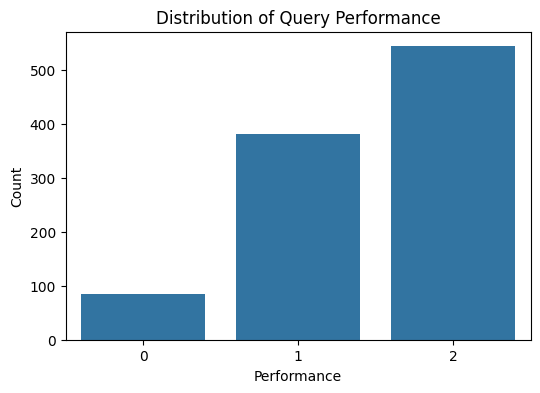

In [148]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Performance')
plt.title('Distribution of Query Performance')
plt.xlabel('Performance')
plt.ylabel('Count')
plt.show()

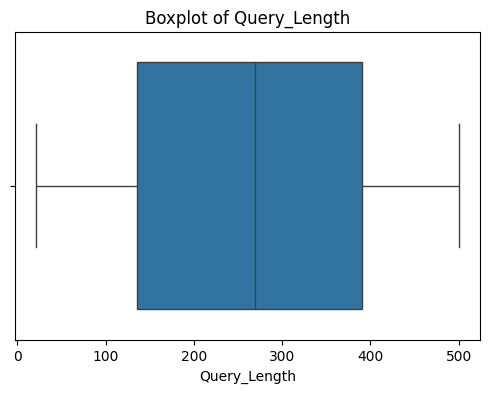

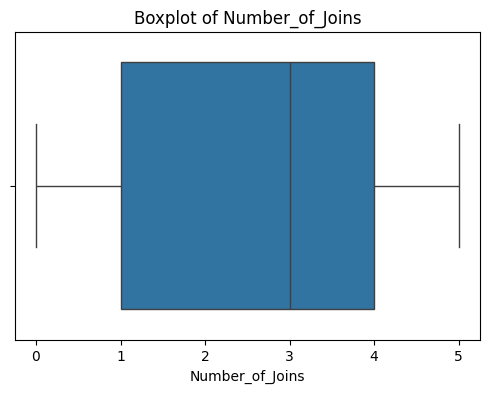

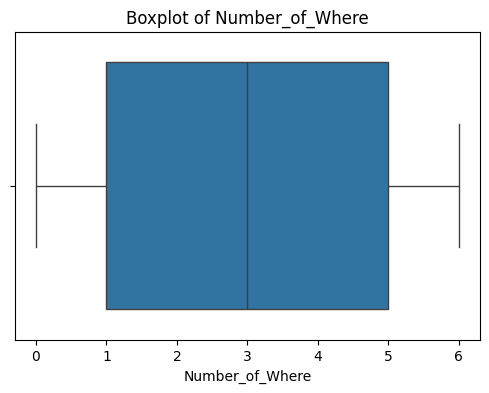

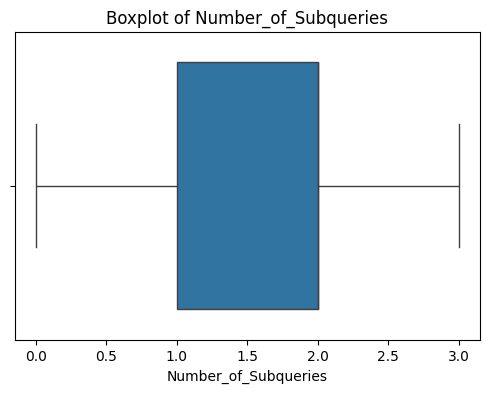

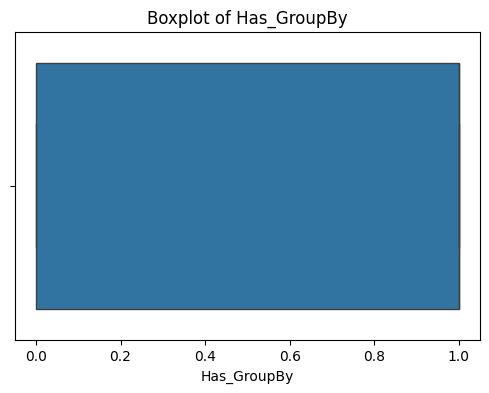

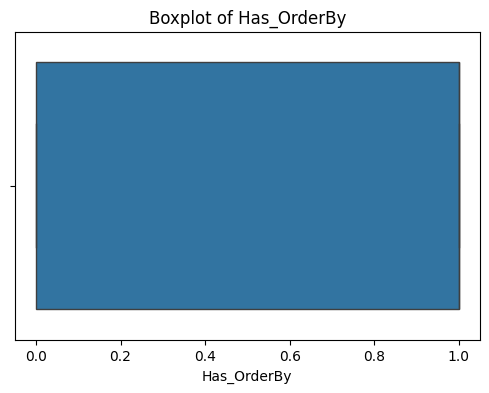

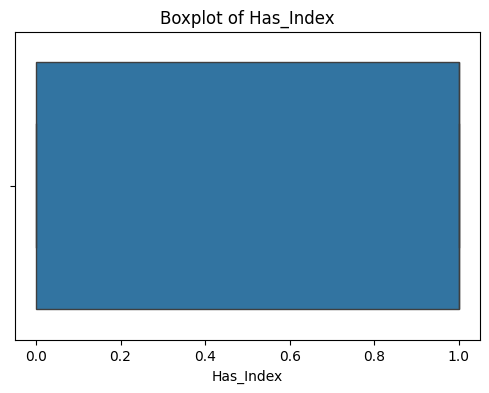

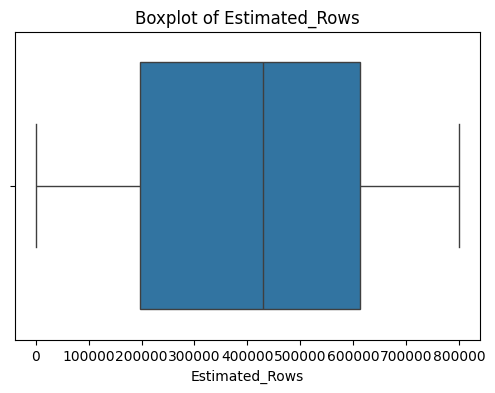

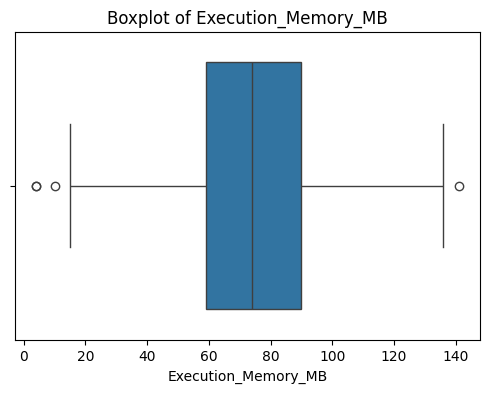

In [149]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])

    plt.title(f'Boxplot of {col}')

    plt.show()

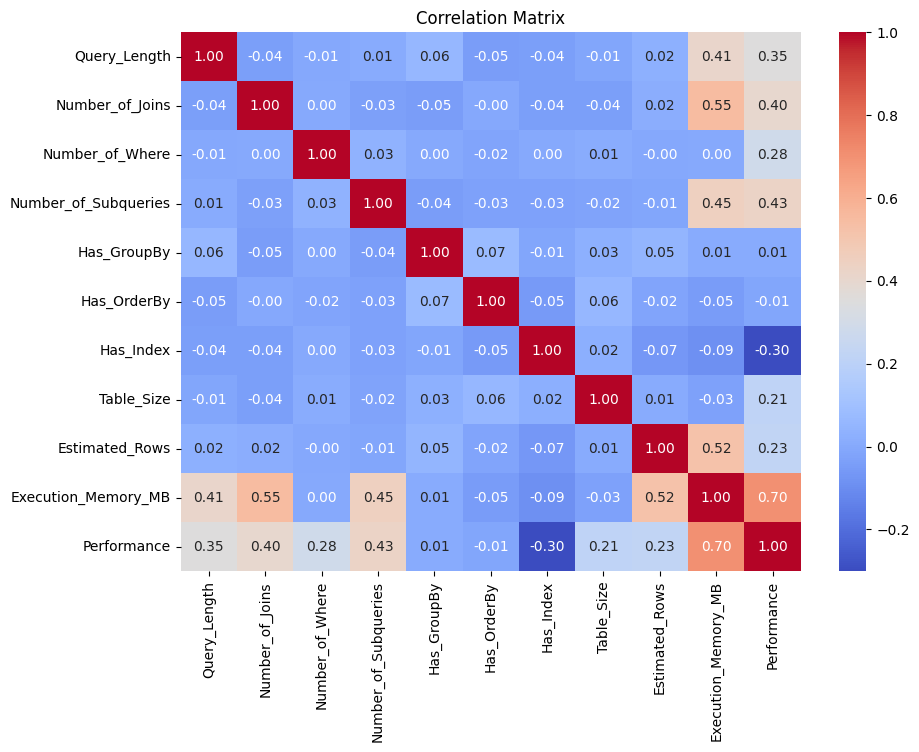

In [150]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,7))
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Correlation Matrix')

plt.show()

In [151]:
df.head()

,Query_Length,Number_of_Joins,Number_of_Where,Number_of_Subqueries,Has_GroupBy,Has_OrderBy,Has_Index,Table_Size,Estimated_Rows,Execution_Memory_MB,Performance
0,347.0,0.0,0.0,2.0,0.0,0.0,0.0,1,709670.0,83.0,1
1,64.0,4.0,3.0,0.0,0.0,0.0,0.0,0,631362.0,64.0,1
2,307.0,1.0,5.0,3.0,0.0,1.0,1.0,2,6914.0,57.0,2
3,377.0,3.0,2.0,2.0,0.0,0.0,1.0,0,398482.0,87.0,2
4,203.0,2.0,4.0,2.0,0.0,1.0,0.0,2,397022.0,67.0,2


In [ ]:
table_size_mapping = {
    'Small': 0,
    'Medium': 1,
    'Large': 2
}

df['Table_Size'] = df['Table_Size'].map(table_size_mapping)

In [ ]:
df['Table_Size'].head()

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Performance'] = le.fit_transform(df['Performance'])

In [ ]:
df.head()

In [ ]:
import joblib

joblib.dump(le, r"C:\Users\hp\OneDrive\Desktop\DicisionTree\model\performance_encoder.pkl")

In [ ]:
X = df.drop('Performance', axis=1)
y = df['Performance']

In [ ]:
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

In [ ]:
dt_model = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)

In [ ]:
dt_model.fit(X_train, y_train)

In [ ]:
y_pred = dt_model.predict(X_test)

In [ ]:
print("Actual Values   :", y_test.values[:10])
print("Predicted Values:", y_pred[:10])

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)

In [ ]:
dt_model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

In [ ]:
dt_model.fit(X_train,y_train)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Accuracy:", grid.best_score_)

In [153]:
import joblib
joblib.dump(dt_model,r"C:\Users\hp\OneDrive\Desktop\DicisionTree\model\sqlprj.pkl")

['C:\\Users\\hp\\OneDrive\\Desktop\\DicisionTree\\model\\sqlprj.pkl']

In [154]:
model = joblib.load(r"C:\Users\hp\OneDrive\Desktop\DicisionTree\model\sqlprj.pkl")

array([1, 2, 1, 2, 2, 1, 2, 1, 2, 1, 1, 2, 0, 0, 2, 1, 1, 2, 2, 2, 1, 0,
       2, 1, 1, 2, 1, 2, 2, 1, 2, 2, 2, 2, 1, 1, 1, 1, 0, 2, 1, 2, 2, 2,
       1, 1, 2, 2, 1, 1, 2, 2, 2, 2, 2, 1, 2, 2, 0, 1, 2, 2, 2, 2, 2, 1,
       2, 2, 2, 2, 2, 1, 2, 2, 1, 2, 2, 1, 1, 2, 2, 2, 1, 2, 1, 2, 0, 2,
       1, 1, 2, 2, 1, 2, 2, 2, 2, 1, 2, 2, 1, 2, 2, 2, 2, 1, 1, 2, 2, 2,
       1, 2, 2, 2, 0, 2, 1, 2, 2, 2, 1, 2, 2, 2, 1, 0, 0, 2, 1, 1, 0, 2,
       1, 1, 2, 1, 2, 1, 2, 2, 2, 1, 1, 1, 0, 2, 2, 0, 1, 1, 2, 1, 2, 1,
       1, 1, 2, 2, 1, 1, 2, 0, 2, 2, 1, 0, 2, 2, 1, 0, 2, 1, 2, 2, 2, 0,
       2, 1, 2, 2, 0, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 1, 2, 2, 1, 1,
       1, 1, 1, 2])

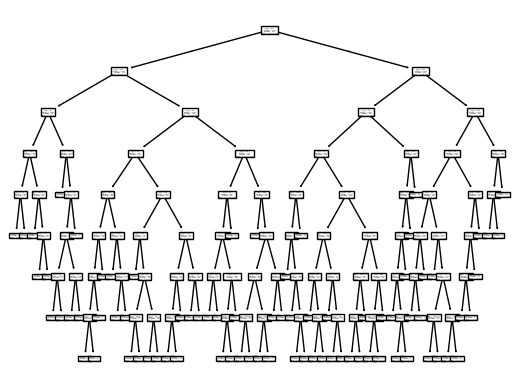

In [155]:
plot_tree(dt_model)

dt_model.predict(X_test)

In [141]:
sample = [[
    150,      # Query_Length
    2,        # Number_of_Joins
    3,        # Number_of_Where
    1,        # Number_of_Subqueries
    1,        # Has_GroupBy
    0,        # Has_OrderBy
    1,        # Has_Index
    1,        # Table_Size (Medium)
    50000,    # Estimated_Rows
    20        # Execution_Memory_MB
]]

prediction = model.predict(sample)

print("Predicted Class:", le.inverse_transform(prediction))

Predicted Class: ['Fast']


C:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
